# IzzyViz Use Case 1: Exploring RAG Attention Behavior

This notebook demonstrates the IzzyViz workflow on one RAG-style extractive QA example.

Workflow:

**Dataset Overview -> Attention Tensors -> Overview -> Select -> Inspect -> Explore**

Research focus:

- The base SQuAD-style context, question, and gold answer stay fixed.
- We add one retrieved context that contains the answer phrase and repeated answer-related evidence.
- We use IzzyViz to inspect whether attention heads focus on answer-bearing spans, repeated evidence, or structural tokens such as prompt prefixes and sinks.

The notebook generates the selected RAG example from the included dataset. It does not rely on pre-rendered local experiment images.

## 0. Clone and Install IzzyViz

This use case can be opened directly from GitHub/Colab. The setup cell below finds an existing local `IzzyViz` checkout or clones `https://github.com/zoeyada/IzzyViz.git`, then installs it in editable mode.

The notebook reads precomputed experiment outputs when available. If outputs are missing, set the corresponding `RUN_*_EXPERIMENT_IF_MISSING` flag to `True` to regenerate them. Regeneration loads large language models and can take substantial time.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/zoeyada/IzzyViz.git'
REPO_NAME = 'IzzyViz'

def find_or_clone_project_dir():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'izzyviz').is_dir() and (candidate / 'workflow').is_dir():
            return candidate

    workspace = Path('/content') if Path('/content').exists() else cwd
    repo_dir = workspace / REPO_NAME
    if not repo_dir.exists():
        subprocess.check_call(['git', 'clone', REPO_URL, str(repo_dir)])
    return repo_dir.resolve()

PROJECT_DIR = find_or_clone_project_dir()
os.chdir(PROJECT_DIR)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(PROJECT_DIR)])

def ensure_numpy_pandas_abi():
    check_code = "import numpy, pandas; import numpy.random; print(numpy.__version__, pandas.__version__)"
    result = subprocess.run([sys.executable, '-c', check_code], text=True, capture_output=True)
    if result.returncode == 0:
        print('NumPy/Pandas:', result.stdout.strip())
        return

    print('Repairing NumPy/Pandas binary install:')
    print((result.stderr or result.stdout).strip().splitlines()[-1])
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        '--force-reinstall',
        '--no-cache-dir',
        'numpy==1.26.4',
        'pandas==2.2.2',
    ])

ensure_numpy_pandas_abi()
print('Using IzzyViz project:', PROJECT_DIR)


Using IzzyViz project: /home/cuizhouying/IzzyViz


## 1. Setup and Dataset Overview

This first overview is only about the RAG dataset content. It does not use model attention, clustering, or any computed visualization result.

Key parameters:

- `TARGET_CTX_ID`: the retrieved context to run through the full IzzyViz workflow.
- `ANSWER`: the gold SQuAD answer used as the analysis anchor.
- `FORCE_REGENERATE_RAG_EXAMPLE`: if `True`, rerun model inference for the selected context so the notebook shows generated outputs.

In [2]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Image, IFrame, Markdown

PROJECT_DIR = Path(PROJECT_DIR) if 'PROJECT_DIR' in globals() else Path.cwd()
if PROJECT_DIR.name != 'IzzyViz' and (PROJECT_DIR.parent / 'izzyviz').exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / 'workflow' / 'rag_cluster' / 'rag_contexts_answer_bearing'
OUTPUT_ROOT = DATASET_DIR / 'exp_function'
CONTEXTS_PATH = DATASET_DIR / 'external_contexts.json'

TARGET_CTX_ID = 'ctx_ac_005'
ANSWER = 'Lobund Institute for Animal Studies'
ANSWER_WORDS = ['lobund', 'institute', 'animal', 'studies']
FORCE_REGENERATE_RAG_EXAMPLE = True

if not CONTEXTS_PATH.exists():
    raise FileNotFoundError(f'Missing RAG dataset: {CONTEXTS_PATH}')

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def count_answer_word_hits(text):
    text_l = text.lower()
    return sum(text_l.count(word) for word in ANSWER_WORDS)

contexts = load_json(CONTEXTS_PATH)
if TARGET_CTX_ID not in contexts:
    raise KeyError(f'{TARGET_CTX_ID} was not found in {CONTEXTS_PATH}')

dataset_rows = []
for ctx_id, item in contexts.items():
    answer_overlap = item.get('answer_overlap') or {}
    text = item.get('text', '')
    dataset_rows.append({
        'ctx_id': ctx_id,
        'length': int(item.get('length', -1)),
        'relatedness': item.get('relatedness', 'unknown'),
        'full_answer_present': bool(answer_overlap.get('full_answer_present', False)),
        'answer_overlap_ratio': float(answer_overlap.get('overlap_ratio', 0.0) or 0.0),
        'answer_word_hits': count_answer_word_hits(text),
        'text_preview': text[:260].replace('\n', ' '),
    })

dataset_df = pd.DataFrame(dataset_rows).sort_values(['relatedness', 'full_answer_present', 'length', 'ctx_id']).reset_index(drop=True)
target_item = contexts[TARGET_CTX_ID]
target_answer_overlap = target_item.get('answer_overlap') or {}

print('Project:', PROJECT_DIR)
print('Dataset:', DATASET_DIR)
print('Number of retrieved contexts:', len(dataset_df))
print('Target context:', TARGET_CTX_ID)
print('Target length:', target_item.get('length'))
print('Target relatedness:', target_item.get('relatedness'))
print('Target contains full answer:', target_answer_overlap.get('full_answer_present'))
print('Target answer word hits:', count_answer_word_hits(target_item.get('text', '')))

display(dataset_df[['ctx_id', 'relatedness', 'length', 'full_answer_present', 'answer_overlap_ratio', 'answer_word_hits']].head(12))

Project: /home/cuizhouying/IzzyViz
Dataset: /home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing
Number of retrieved contexts: 58
Target context: ctx_ac_005
Target length: 1536
Target relatedness: high
Target contains full answer: True
Target answer word hits: 9


,ctx_id,relatedness,length,full_answer_present,answer_overlap_ratio,answer_word_hits
0,ctx_ac_016,high,96,False,0.25,2
1,ctx_ac_021,high,97,False,0.25,2
2,ctx_ac_017,high,192,False,0.25,2
3,ctx_ac_022,high,196,False,0.75,5
4,ctx_ac_023,high,385,False,0.75,9
5,ctx_ac_018,high,389,False,0.25,2
6,ctx_0009,high,400,False,0.25,2
7,ctx_0023,high,400,False,0.25,1
8,ctx_0010,high,641,False,1.00,12
9,ctx_ac_019,high,768,False,0.50,4


Target retrieved context preview:
seasons, won the Rose Bowl Game in 1925, and produced players such as George Gipp and the "Four Horsemen". Knute Rockne has the highest winning percentage (.881) in NCAA Division I/FBS football history. Rockne's offenses employed the Notre Dame Box and his defenses ran a 7–2–2 scheme. The success of Notre Dame reflected the rising status of Irish Americans and Catholics in the 1920s. Catholics rallied around the team and listened to the games on the radio, especially when it defeated teams from schools that symbolized the Protestant establishment in the United States — Harvard, Yale, Princeton, and Army. Its role as a high-profile flagship institution of Catholicism made it an easy target of anti-Catholicism. The most remarkable episode of violence was a clash in 1924 between Notre Dame students and the Ku Klux Klan (KKK), a white supremacist and anti-Catholic movement. The Klan decided 


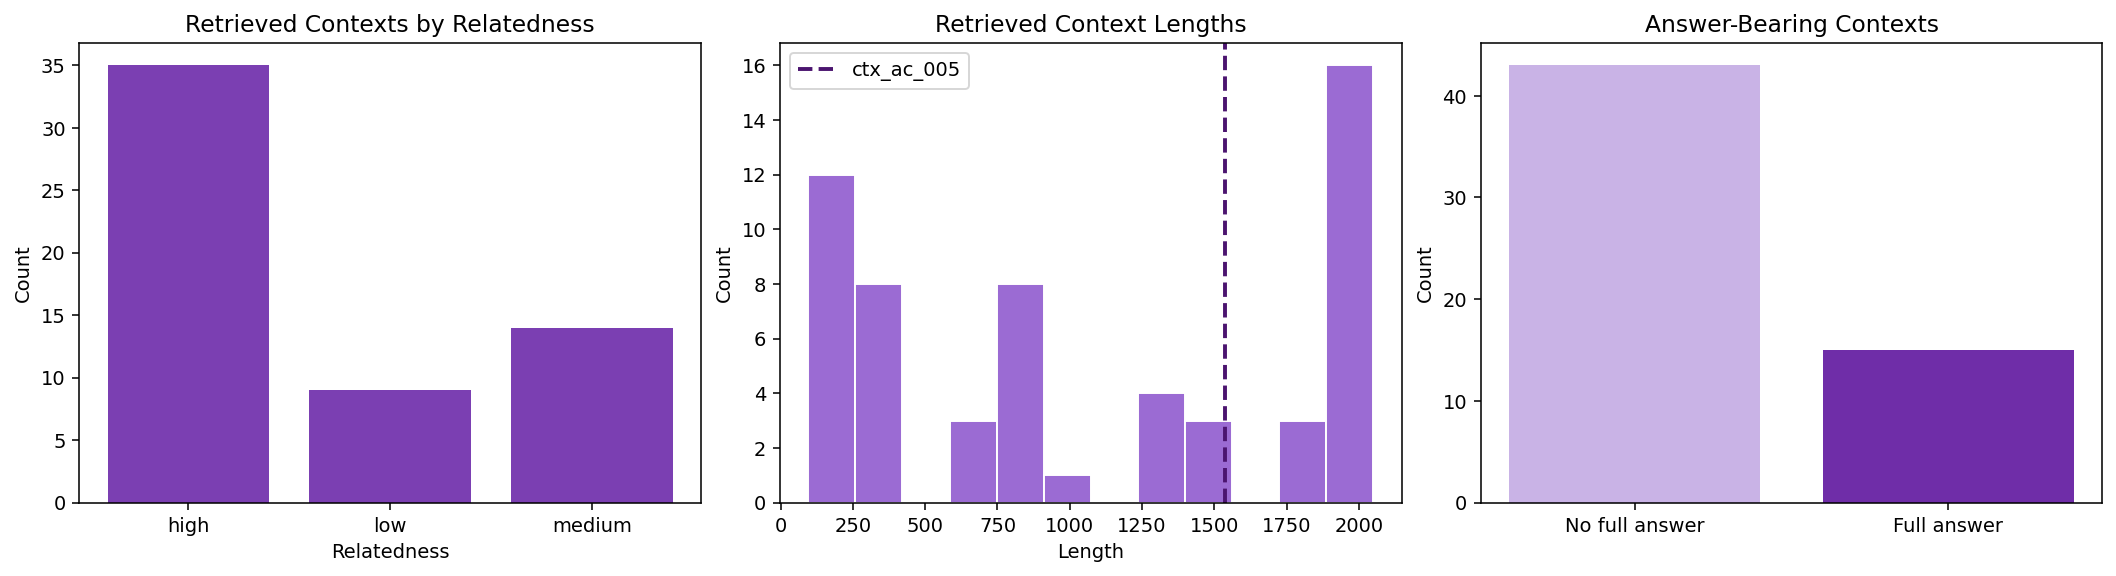

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

related_counts = dataset_df['relatedness'].value_counts().sort_index()
axes[0].bar(related_counts.index.astype(str), related_counts.values, color='#7b3fb2')
axes[0].set_title('Retrieved Contexts by Relatedness')
axes[0].set_xlabel('Relatedness')
axes[0].set_ylabel('Count')

axes[1].hist(dataset_df['length'], bins=12, color='#9b6bd3', edgecolor='white')
axes[1].axvline(target_item.get('length'), color='#4b146f', linestyle='--', linewidth=2, label=TARGET_CTX_ID)
axes[1].set_title('Retrieved Context Lengths')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
axes[1].legend()

answer_counts = dataset_df['full_answer_present'].value_counts().reindex([False, True], fill_value=0)
axes[2].bar(['No full answer', 'Full answer'], answer_counts.values, color=['#c9b3e6', '#6f2da8'])
axes[2].set_title('Answer-Bearing Contexts')
axes[2].set_ylabel('Count')

plt.show()

print('Target retrieved context preview:')
print(target_item.get('text', '')[:900])

## 2. Attention Tensors

This block runs Qwen2.5-1.5B on the selected RAG prompt and asks the model to return attention tensors.

Important parameters passed to the generation script:

- `IZZYVIZ_CONTEXT_IDS`: limits the run to `TARGET_CTX_ID`, so the notebook only generates one RAG example.
- `IZZYVIZ_FORCE_RERUN`: reruns the example when `FORCE_REGENERATE_RAG_EXAMPLE=True`.
- `IZZYVIZ_HF_LOCAL_FILES_ONLY`: set to `0` so Colab can download the model if it is not cached.

The script then calls IzzyViz functions to produce overview images, clustering outputs, and representative head heatmaps.

In [4]:
def find_run_dir_for_context(output_root, ctx_id):
    for summary_path in sorted(Path(output_root).glob('*/run_summary.json')):
        meta_path = summary_path.parent / 'function_run_context.json'
        if meta_path.exists():
            meta = load_json(meta_path)
            if meta.get('ctx_id') == ctx_id:
                return summary_path.parent
    return None

def run_rag_example():
    script = PROJECT_DIR / 'workflow' / 'rag_cluster' / 'run_answer_bearing_cluster_function.py'
    if not script.exists():
        raise FileNotFoundError(f'Missing RAG generation script: {script}')
    env = os.environ.copy()
    env['IZZYVIZ_CONTEXT_IDS'] = TARGET_CTX_ID
    env['IZZYVIZ_FORCE_RERUN'] = '1' if FORCE_REGENERATE_RAG_EXAMPLE else env.get('IZZYVIZ_FORCE_RERUN', '0')
    env.setdefault('IZZYVIZ_HF_LOCAL_FILES_ONLY', '0')
    print('Generating attention tensors and IzzyViz outputs:')
    print('  target context:', TARGET_CTX_ID)
    print('  force rerun:', env['IZZYVIZ_FORCE_RERUN'])
    subprocess.check_call([sys.executable, str(script)], cwd=str(PROJECT_DIR), env=env)

if FORCE_REGENERATE_RAG_EXAMPLE or find_run_dir_for_context(OUTPUT_ROOT, TARGET_CTX_ID) is None:
    run_rag_example()

RUN_DIR = find_run_dir_for_context(OUTPUT_ROOT, TARGET_CTX_ID)
if RUN_DIR is None:
    raise FileNotFoundError(f'No generated run was found for {TARGET_CTX_ID} under {OUTPUT_ROOT}')

run_summary = load_json(RUN_DIR / 'run_summary.json')
run_meta = load_json(RUN_DIR / 'function_run_context.json')
output_paths = {k: Path(v) if isinstance(v, str) else v for k, v in run_meta.get('output_paths', {}).items()}

print('Generated run directory:', RUN_DIR)
print('Sequence length:', run_meta.get('seq_len'))
print('Question end token index:', run_meta.get('question_end'))
print('Answer start token index:', run_meta.get('answer_start'))
print('Number of clusters:', run_summary.get('n_clusters'))
print('Cluster sizes:', run_summary.get('cluster_sizes'))

Generating attention tensors and IzzyViz outputs:
  target context: ctx_ac_005
  force rerun: 1
Generated run directory: /home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high
Sequence length: 1890
Question end token index: 1882
Answer start token index: 1884
Number of clusters: 5
Cluster sizes: {'0': 21, '1': 22, '2': 16, '3': 47, '4': 230}


## 3. Overview

The overview presents the entire Layer × Head space for the selected RAG prompt.

Parameters used by the generated overview:

- `plot_overview_no_merge=True`: show an overview without virtual-token merging.
- `plot_overview_merge=True`: show a long-context overview with merged token regions, which is easier to inspect for long retrieved passages.
- `overview_top_n=3`: mark the most important token regions in each head-level thumbnail.

For this RAG example, the merge-token overview is usually the most readable first view because the prompt is long.

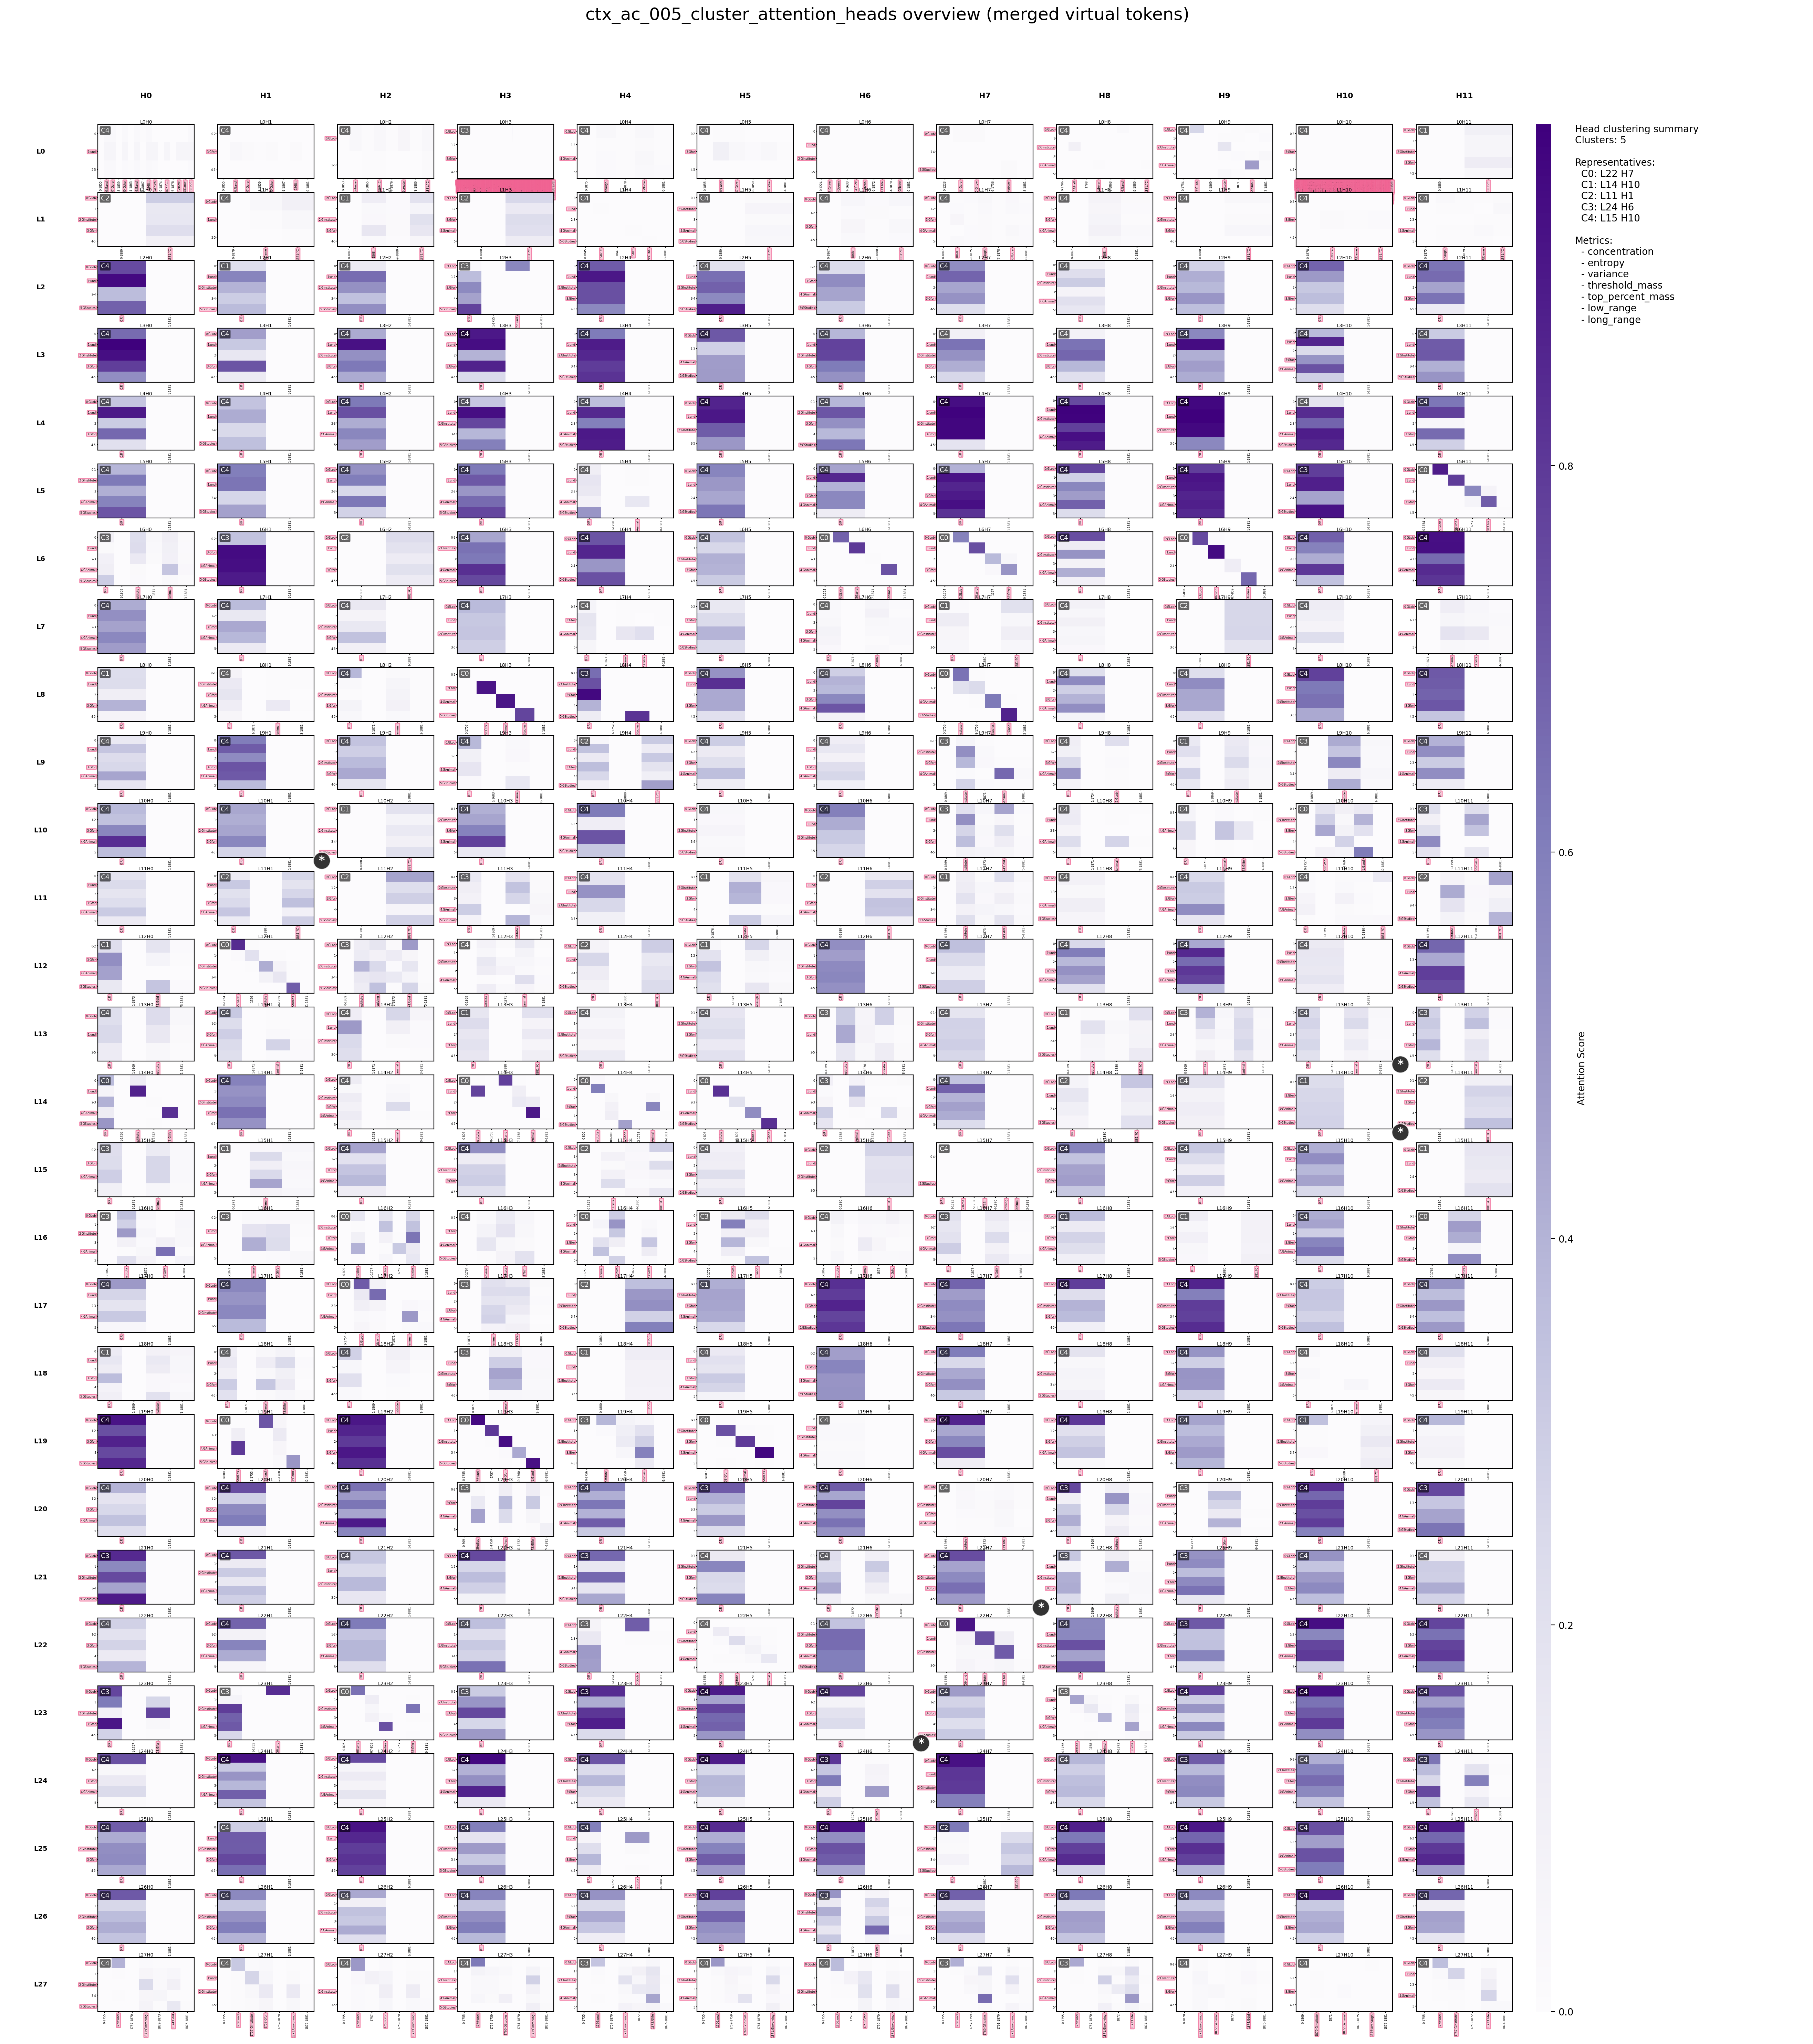

In [5]:
def show_image(path, width=1100):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path), width=width))

show_image(RUN_DIR / 'overview_merge_tokens.png', width=1150)

## 4. Select

The Select step reduces the number of heads that need manual inspection.

This RAG workflow uses clustering-based representative head selection:

- Each attention head is converted into feature vectors using IzzyViz attention metrics such as entropy, variance, threshold mass, top-percent mass, low-range dependency, and long-range dependency.
- Heads are clustered with Ward clustering.
- One representative head is selected per cluster.

The PCA plot shows the feature-space organization of heads, and the table lists the representative Layer/Head pairs selected for inspection.

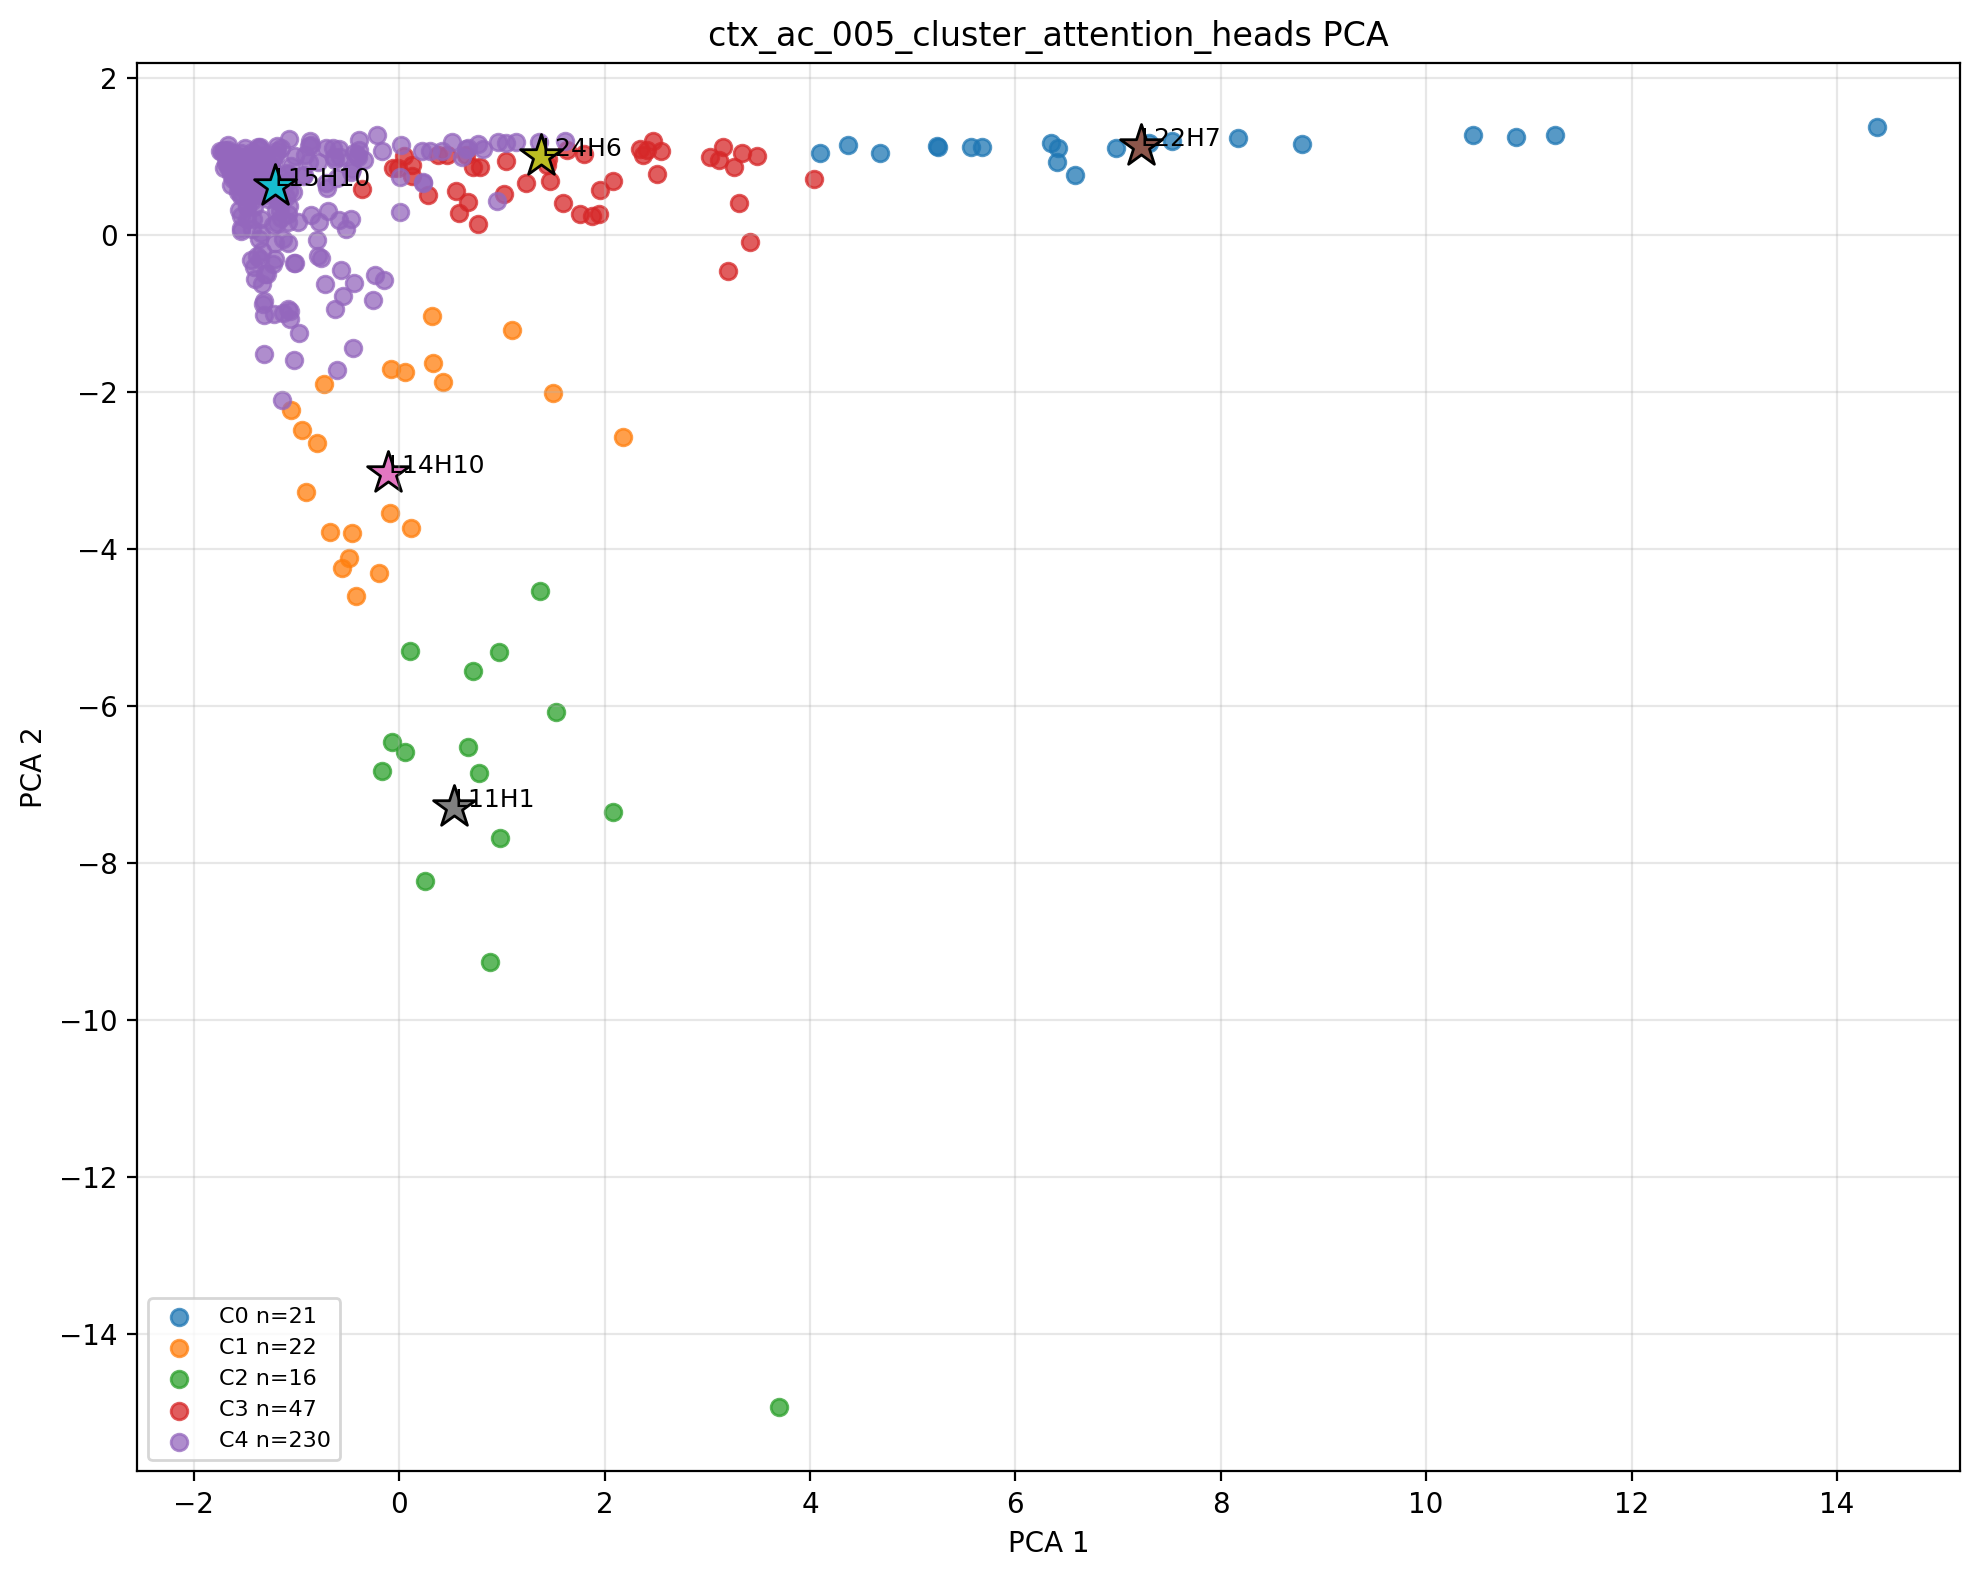

,cluster,layer,head,cluster_size
0,0,22,7,21
1,1,14,10,22
2,2,11,1,16
3,3,24,6,47
4,4,15,10,230


In [6]:
representatives = run_summary.get('representatives', [])
cluster_sizes = {int(k): int(v) for k, v in run_summary.get('cluster_sizes', {}).items()}
rep_df = pd.DataFrame([
    {
        'cluster': rep.get('cluster'),
        'layer': rep.get('layer'),
        'head': rep.get('head'),
        'cluster_size': cluster_sizes.get(int(rep.get('cluster')), np.nan),
    }
    for rep in representatives
]).sort_values('cluster').reset_index(drop=True)

show_image(RUN_DIR / 'pca_scatter.png', width=900)
display(rep_df)

## 5. Inspect

The Inspect step opens the detailed IzzyViz heatmaps for representative heads.

How to read the outputs:

- `overview_no_merge` is useful for seeing the original token-index layout.
- Representative detail heatmaps show the full attention matrix for selected heads.
- For answer-bearing RAG, focus on whether the answer output tokens attend to the retrieved answer phrase, the original context answer span, repeated evidence, or prompt-format tokens.

You can change `DETAIL_HEATMAP_LIMIT` to show more or fewer representative heads.

Run metadata:


,ctx_id,relatedness,retrieved_context_length,seq_len,question_end,answer_start,full_answer_present,answer_overlap_ratio,answer_word_hits
0,ctx_ac_005,high,1536,1890,1882,1884,True,1.0,9


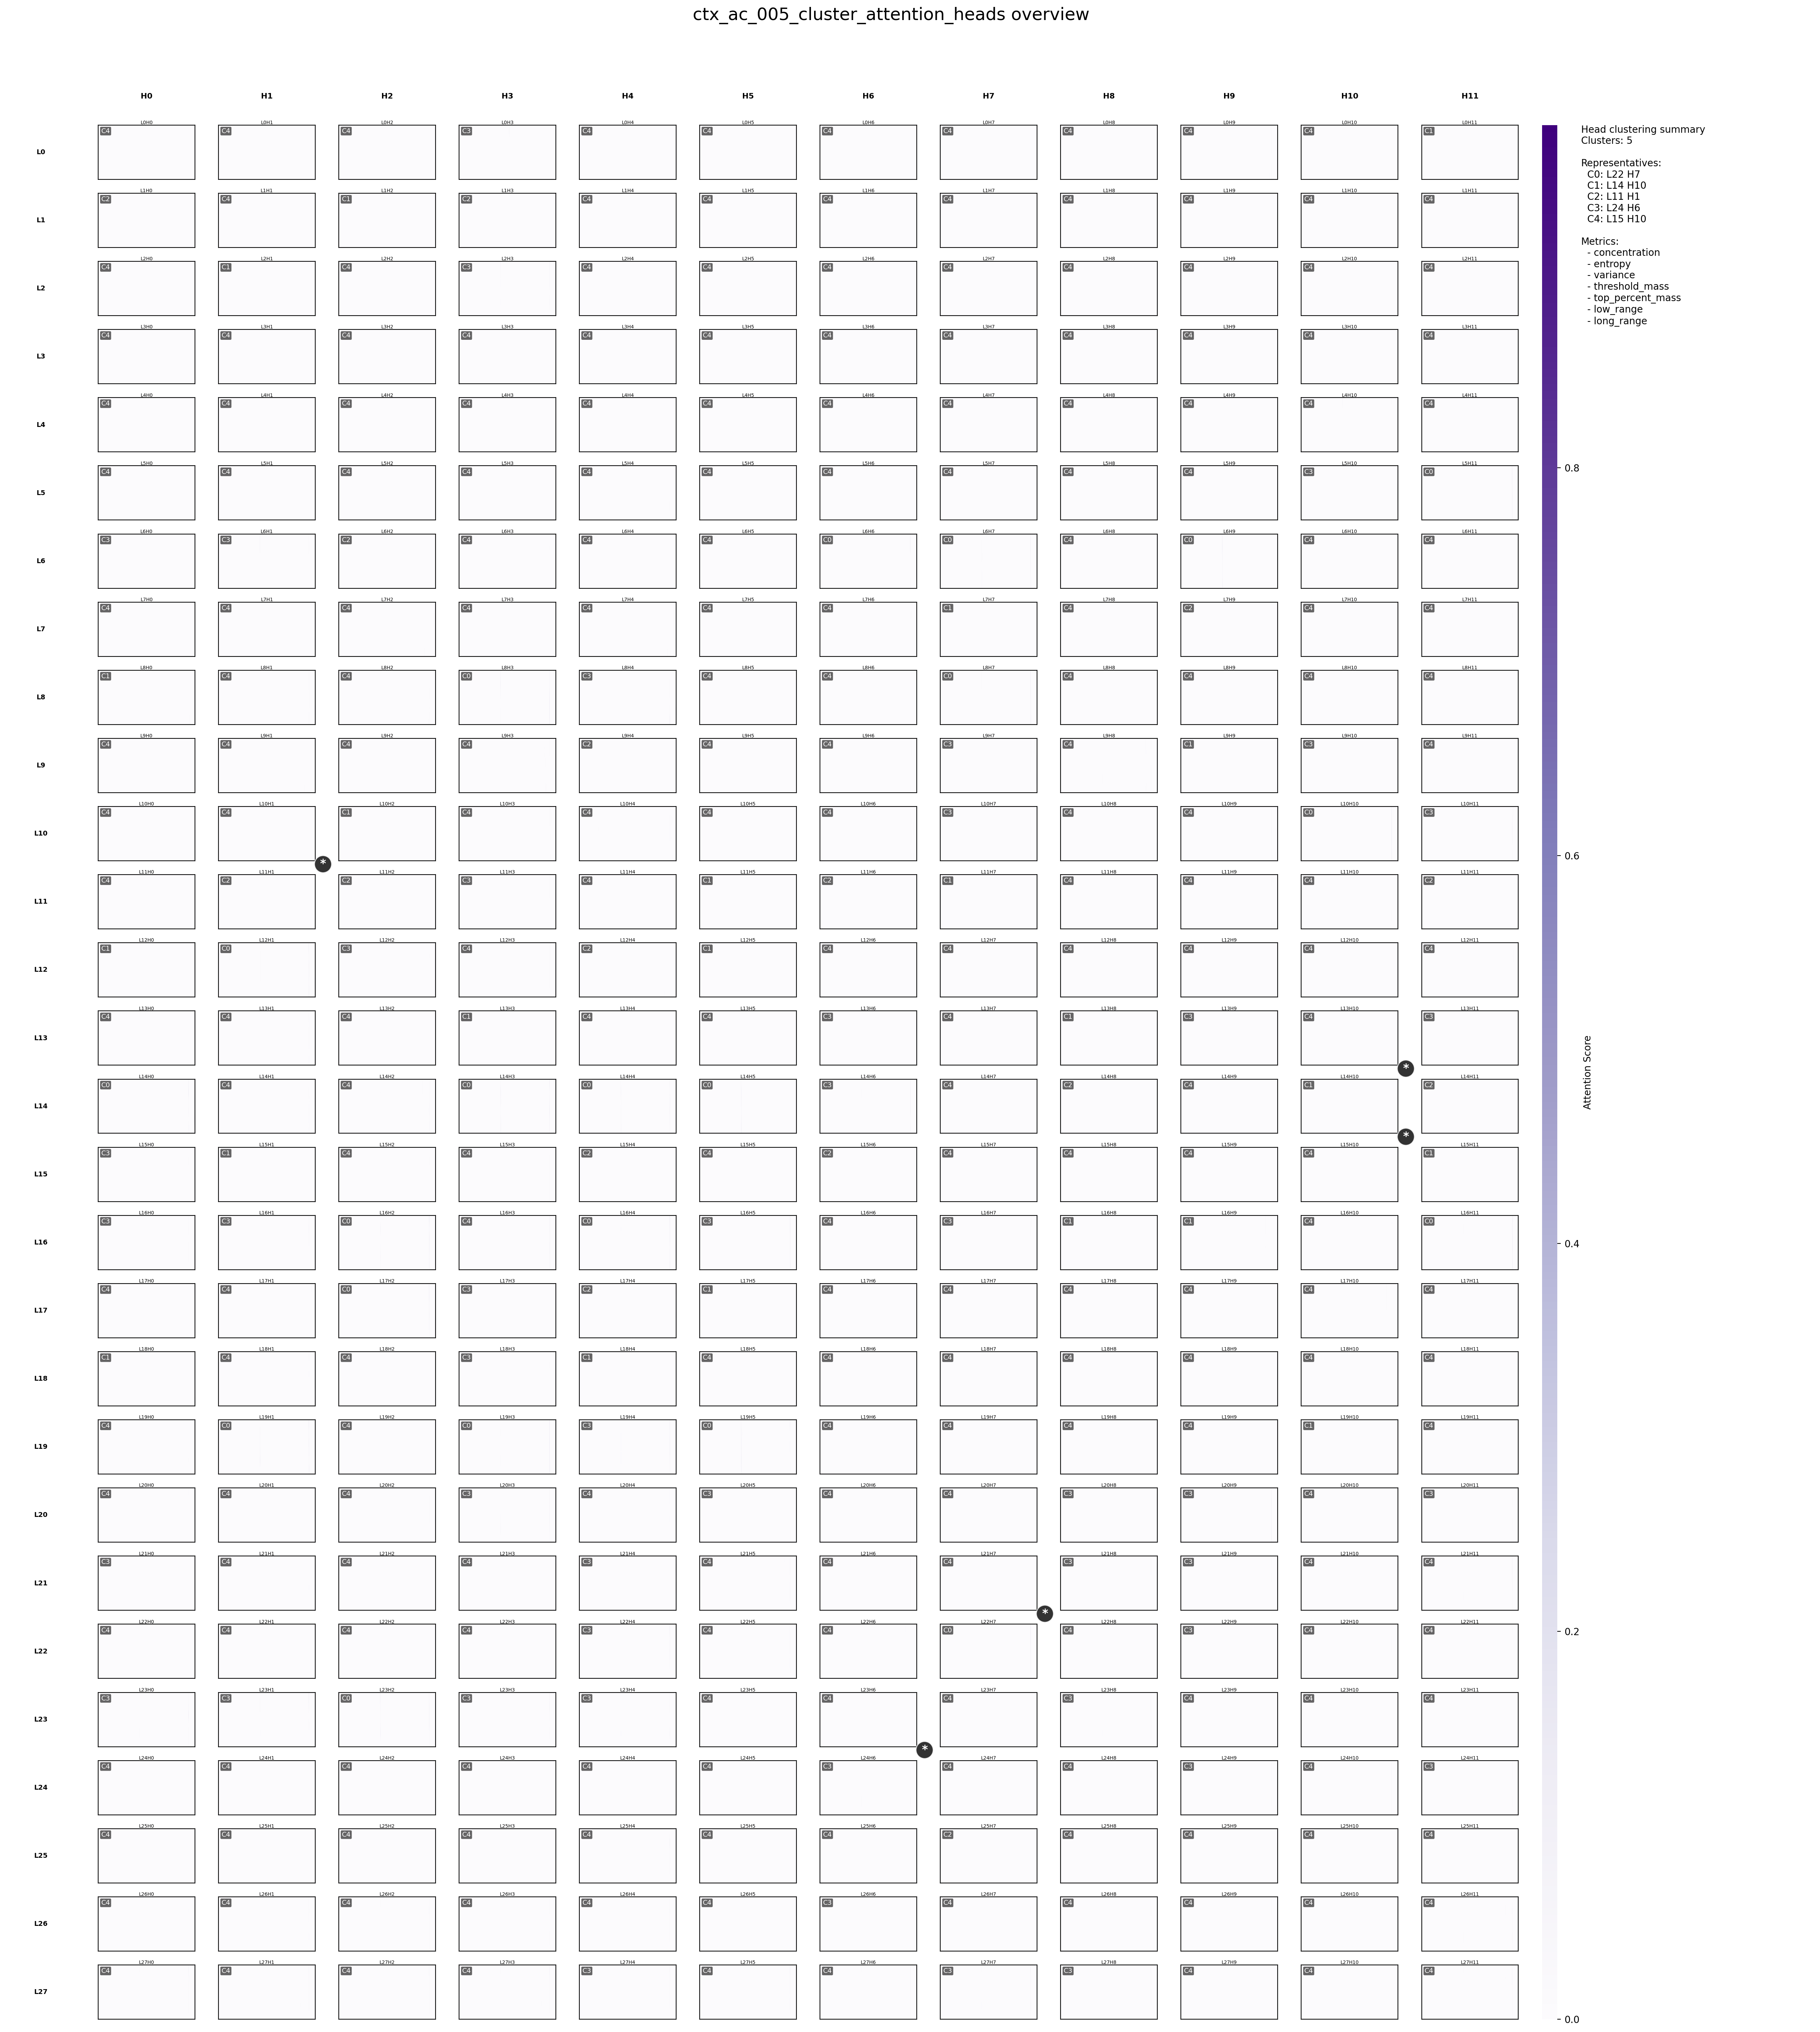

### Representative Detail Heatmaps

**cluster_0_L22_H7.pdf**

IFrame(/home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high/cluster_0_L22_H7.pdf)

**cluster_1_L14_H10.pdf**

IFrame(/home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high/cluster_1_L14_H10.pdf)

...

IFrame(/home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high/cluster_2_L11_H1.pdf)

**cluster_3_L24_H6.pdf**

IFrame(/home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high/cluster_3_L24_H6.pdf)

**cluster_4_L15_H10.pdf**

IFrame(/home/cuizhouying/IzzyViz/workflow/rag_cluster/rag_contexts_answer_bearing/exp_function/ctx_ac_005_1536_high/cluster_4_L15_H10.pdf)

In [7]:
DETAIL_HEATMAP_LIMIT = 5

print('Run metadata:')
display(pd.DataFrame([{
    'ctx_id': run_meta.get('ctx_id'),
    'relatedness': run_meta.get('relatedness'),
    'retrieved_context_length': run_meta.get('length'),
    'seq_len': run_meta.get('seq_len'),
    'question_end': run_meta.get('question_end'),
    'answer_start': run_meta.get('answer_start'),
    'full_answer_present': target_answer_overlap.get('full_answer_present'),
    'answer_overlap_ratio': target_answer_overlap.get('overlap_ratio'),
    'answer_word_hits': count_answer_word_hits(target_item.get('text', '')),
}]))

show_image(RUN_DIR / 'overview_no_merge.png', width=1150)

detail_heatmaps = [Path(p) for p in output_paths.get('detail_heatmaps', [])]
if not detail_heatmaps:
    detail_heatmaps = sorted(RUN_DIR.glob('cluster_*_L*_H*.pdf'))

display(Markdown('### Representative Detail Heatmaps'))
for pdf in detail_heatmaps[:DETAIL_HEATMAP_LIMIT]:
    display(Markdown(f'**{pdf.name}**'))
    display(IFrame(src=str(pdf), width=920, height=560))

## 6. Explore: RAG-Specific Questions

This final section is for interpretation rather than another computation block.

For the demo paper, this use case can support questions such as:

- In extractive QA, do any heads clearly attend to answer-bearing tokens or nearby context?
- When retrieved evidence repeats answer-related content, does attention split across repeated spans or concentrate on one occurrence?
- Are representative heads driven by answer evidence, long-range retrieval structure, or persistent attention sinks?
- Does the long retrieved passage create distinctive long-range dependency heads, or does the model mostly preserve the same structural patterns as the non-RAG prompt?

Observation notes to fill after inspection:

- TODO: Which representative Layer/Head pairs show visible answer-neighborhood attention?
- TODO: Does the model prefer the retrieved context answer span or the original context answer span?
- TODO: Are the most visually salient structures answer-related, or dominated by sinks/format tokens?
- TODO: Which figure is strongest for the EMNLP demo paper: overview, PCA selection, or a representative detailed heatmap?